# __Recommendation Systems__

## __Agenda__

# **1.1 Overview of Recommendation Systems**

## **1.1.1 What are Recommendation Systems?**

Recommendation Systems are software tools and algorithms that provide suggestions for products, services, or information to users. The suggestions are tailored to the user’s preferences, based on data about their previous behavior and preferences.


The underlying function of a recommendation system can be represented as:
$$ f: \text{User} \times \text{Item} \rightarrow \text{Rating} $$



- **f**: represents the predictive function that estimates the utility (or rating) of an item for a particular user.

- **User**: represents the set of all users in the system. Each user is a potential recipient of recommendations.

- **Item**: represents the set of all items available for recommendation. These can include products, services, media content, or any other entities that the system recommends.

- **Rating**: represents predicted rating or preference score that a user would give to an item, which can be used to generate personalized recommendations.



![link text](http://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_07/recommendation_system_edited.png)

# __1.2 Examples of Recommendation System__

Let's explore how recommendation systems enhance user experiences across various platforms by providing personalized suggestions, from books and media to products tailored to individual preferences. We'll delve into specific examples, showcasing the profound impact of these systems in different industries.


### __1.2.1 Enhanced Book Discovery Recommendations__

Goodreads' __READERS ALSO ENJOYED__ and __See similar books__ features suggest books based on user preferences and past reads, enhancing discovery and facilitating exploration of similar titles.

### Mathematical Concept:
To calculate the similarity between two users or items, Pearson correlation may be used:

$$
r = \frac{\sum (x - \overline{x})(y - \overline{y})}{\sqrt{\sum (x - \overline{x})^2} \sqrt{\sum (y - \overline{y})^2}}
$$

Where:

$$
\text{• } \textbf{x} \text{ and } \textbf{y} \text{ are the ratings given by two different users to the same items.}
$$

$$
\text{• } \overline{x} \text{ and } \overline{y} \text{ represent the average ratings given for those items by the two users.}
$$








This formula measures how closely the ratings by two users (or two items) align, indicating the degree of similarity between their preferences.


![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_08/Enhanced_Recommendations.png)

### __1.2.2 Hyper-Personalized Media Recommendations__

Netflix and Spotify deliver tailored media suggestions by leveraging complex algorithms to analyze users' viewing and listening habits, optimizing content personalization to enhance engagement and satisfaction.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_08/Hyper_Personalized_Media_Recommendations.png)

### __1.2.3 Viewed Items Recommendations__

E-commerce platforms like Amazon enhance shopping experiences by recommending products related to items users have viewed, increasing product visibility and potential sales through smart, context-aware suggestions.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_08/Viewed_Items_Recommendation.png)

### __1.2.4 Enhanced Product Discovery Recommendations__

Retailers like AlvaQ and Fisoew use recommendation systems to suggest more products based on user search behavior. This enhances product discovery and encourages additional purchases.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_08/Enhanced_Product_Discovery_Recommendation.png)

# __1.3 Types of Recommendation Systems__


There are three types of recommendation systems, each utilizing different techniques to generate personalized recommendations:

- Collaborative filtering
- Content filtering
- Hybrid filtering

### __1.3.1 Collaborative Filtering__

Collaborative filtering algorithms recommend items by analyzing user preferences collected from numerous users. They predict future behavior by identifying patterns in historical data, such as which movies users have enjoyed, allowing the system to suggest items with a high likelihood of user agreement.

For example, if two users have similar tastes in movies, the system might recommend a new movie to one user that the other has favorably rated.

## Mathematical Concept:

To quantify the similarity between user preferences, collaborative filtering uses cosine similarity, where user ratings are vectors in a multidimensional space:
$$
\text{similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\|\|\mathbf{B}\|}
$$
Where:
- $\mathbf{A}$ and $\mathbf{B}$ are vectors representing user ratings.
- $\theta$ is the angle between these vectors, which indicates the degree of similarity in user preferences.


A smaller angle (or higher cosine similarity) indicates more closely aligned preferences, suggesting that users will likely enjoy similar items. This approach enables more precise recommendations based on shared user interests.


![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_08/Collaborative_Filtering.png)

There are mainly two types of collaborative filtering techniques:

- Memory-based collaborative filtering
- Model-based collaborative filtering

### __.3.1.1 Memory-Based Collaborative Filtering__

Memory-based collaborative filtering is a fundamental approach within recommendation systems that generates predictions based on the entire database of user-item interactions. This method leverages historical data from user ratings to recommend new items or predict user ratings. It operates on the assumption that those who agreed in the past will agree again in the future.

There are two primary strategies within memory-based collaborative filtering:

- User-based collaborative filtering
- Item-based collaborative filtering

### __User-Based Collaborative Filtering__

User-based collaborative filtering is a recommendation technique that suggests items or content to a target user based on the preferences and behaviors of similar users. It operates under the assumption that users who have interacted with similar items in the past will continue to have similar preferences in the future.

#### To measure similarity between two users \(u\) and \(v\), cosine similarity can be used:

The similarity between two users, \( u \) and \( v \), can be quantified using cosine similarity, which is particularly useful in user-based collaborative filtering. The formula for cosine similarity is as follows:

$$
\text{similarity}(u, v) = \cos(\theta) = \frac{\sum_{i \in I} r_{ui} \cdot r_{vi}}{\sqrt{\sum_{i \in I} r_{ui}^2} \cdot \sqrt{\sum_{i \in I} r_{vi}^2}}
$$

#### Variables:
- $r_ui$ and r_vi: Ratings given by users u and v to item i.
- I: The set of items that both users have rated.
- theta: The angle between the rating vectors of u and v, where a smaller angle indicates a higher similarity.


This approach calculates the cosine of the angle between the two users' rating vectors, effectively measuring their similarity based on the items they have both rated.


#### __Example:__

Let's explore an example of user-based collaborative filtering using the `anime.csv` and `rating.csv` datasets. In the `rating.csv` file, each row represents a user's rating for a specific anime. By merging this dataset with `anime.csv` based on anime IDs, you can construct a user-item interaction matrix. In this matrix, rows correspond to users, columns represent anime titles, and the values are the ratings. This matrix is crucial for performing similarity calculations.

To measure the similarity between users' anime preferences, you'll use the `cosine_similarity` function. Here, each user's preferences are depicted as vectors in a high-dimensional space, where each dimension corresponds to an anime title. Cosine similarity quantifies the similarity of these vectors by calculating the cosine of the angle between them. Higher scores suggest a greater similarity among users' preferences.

In [23]:
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import statistics
import operator

The anime.csv dataset contains information about the following columns:

- anime_id: An identifier for the anime
- name: The name of the anime
- genre: The genre(s) of the anime
- type: The type of anime (e.g., TV, Movie)
- episodes: The number of episodes (Note: This is an object type, suggesting some non-numeric values may be present.)
- rating: The rating of the anime
- members: The number of members who have added this anime to their list

In [24]:
# load the data from 'anime.csv' into a DataFrame named 'animes'.
animes = pd.read_csv('anime.csv')
# Display the first five rows of the DataFrame using the 'head()' method to provide a quick overview of the dataset structure and content.
animes.head()
# Use the 'info()' method to output a concise summary of the DataFrame, including the number of non-null entries in each column, the data type of each column, and memory usage.
animes.info()
# Calculates the total number of missing (null) values in each column using the 'isnull().sum()' method, helping to identify columns that might require cleaning or further investigation due to missing data.
animes.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [25]:
animes.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [26]:
animes.shape

(12294, 7)

In [27]:
animes[animes["anime_id"]==1]

,anime_id,name,genre,type,episodes,rating,members
22,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,26,8.82,486824


__Observations:__

- The __genre__ column has 62 missing values, while the __type__ column has 25 missing values.
- The __rating__ column has 230 missing values, indicating a significant portion of the data is absent.
- Other columns, such as __anime_id__, __name__, __episodes__, and __members__, have no missing values.

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Handle missing values
animes['genre'].fillna('Unknown', inplace=True)
animes['type'].fillna('Unknown', inplace=True)

# Convert the 'episodes' column in the 'animes' dataframe to numeric data type using
# the pd.to_numeric() function, with any non-convertible values replaced by 0
animes['episodes'] = pd.to_numeric(animes['episodes'], errors='coerce').fillna(0)

# Fill missing ratings with mean rating
animes['rating'].fillna(animes['rating'].mean(), inplace=True)

C:\Users\Deepak Pandey\AppData\Local\Temp\ipykernel_24520\1701769819.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  animes['genre'].fillna('Unknown', inplace=True)
C:\Users\Deepak Pandey\AppData\Local\Temp\ipykernel_24520\1701769819.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [29]:
# Generate descriptive statistics for the numerical columns of the 'animes' DataFrame
animes.describe()

,anime_id,episodes,rating,members
count,12294.000000,12294.000000,12294.000000,1.229400e+04
mean,14058.221653,12.040101,6.473902,1.807134e+04
std,11455.294701,46.257299,1.017096,5.482068e+04
min,1.000000,0.000000,1.670000,5.000000e+00
25%,3484.250000,1.000000,5.900000,2.250000e+02
50%,10260.500000,2.000000,6.550000,1.550000e+03
75%,24794.500000,12.000000,7.170000,9.437000e+03
max,34527.000000,1818.000000,10.000000,1.013917e+06


In [30]:
type_counts = animes['type'].value_counts()
type_counts

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Unknown      25
Name: count, dtype: int64

In [31]:
genre_counts = animes['genre'].str.split(', ').explode().value_counts().head(10)
genre_counts


genre
Comedy           4645
Action           2845
Adventure        2348
Fantasy          2309
Sci-Fi           2070
Drama            2016
Shounen          1712
Kids             1609
Romance          1464
Slice of Life    1220
Name: count, dtype: int64

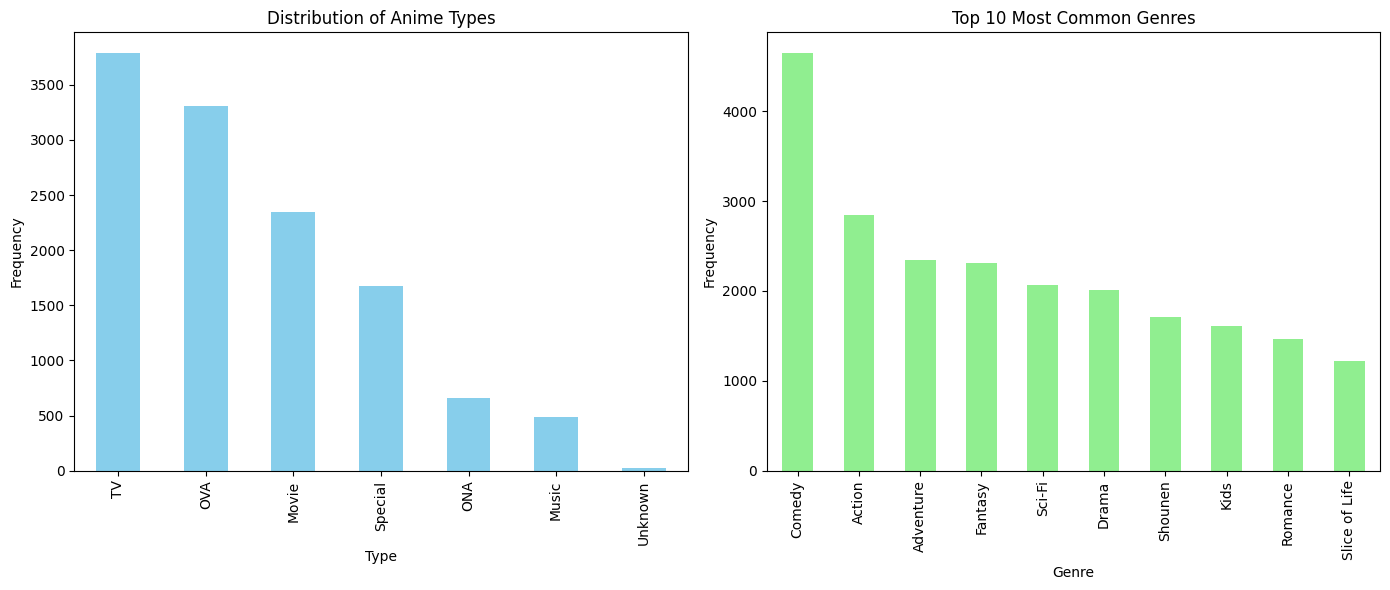

In [32]:
# Analyzing categorical variables
type_counts = animes['type'].value_counts()
genre_counts = animes['genre'].str.split(', ').explode().value_counts().head(10)

# Plotting the distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

type_counts.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Anime Types')
ax[0].set_ylabel('Frequency')
ax[0].set_xlabel('Type')

genre_counts.plot(kind='bar', ax=ax[1], color='lightgreen')
ax[1].set_title('Top 10 Most Common Genres')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Genre')

plt.tight_layout()
plt.show()

__Observations:__

__Distribution of anime types__
- TV and OVA formats dominate the dataset, with movies also being notably common.
- Specials, ONAs, and music types are less prevalent, indicating niche categories.

__Top 10 most common genres__
- Comedy, action, and adventure are the top genres, signifying popular themes in anime.
- Fantasy and sci-fi also feature prominently, reflecting a taste for imaginative storytelling.

- Exploratory Data Analysis (EDA) on __rating__ dataset

In [33]:
# Read the rating.csv file and store its contents in the 'ratings' dataframe
ratings = pd.read_csv('rating.csv')

In [34]:
ratings

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1
...,...,...,...
7813732,73515,16512,7
7813733,73515,17187,9
7813734,73515,22145,10
7813735,73516,790,9


In [35]:
ratings["user_id"].nunique()

73515

In [36]:
ratings[ratings["anime_id"]==20].shape

(25925, 3)

In [37]:
# Exclude rows where the rating is -1 (implying missing or few ratings from individuals)
ratings = ratings[ratings.rating != -1]

# Display the first few rows of the filtered ratings dataset
ratings.head()

,user_id,anime_id,rating
47,1,8074,10
81,1,11617,10
83,1,11757,10
101,1,15451,10
153,2,11771,10


In [38]:
# Display concise summary information about the 'ratings' DataFrame
ratings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6337241 entries, 47 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 193.4 MB


In [39]:
# Count the number of missing values in each column of the 'ratings' DataFrame
ratings.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

__Observation:__
    
- There are no missing values in the user_id, anime_id, and we will drop the row of missing valuse from rating columns of the ratings dataset.

In [40]:
# Handling missing values
# Drop rows with any missing values
ratings_dropped = ratings.dropna()

In [41]:
# Generate descriptive statistics for the numerical columns of the 'ratings' DataFrame
ratings.describe()

,user_id,anime_id,rating
count,6.337241e+06,6.337241e+06,6.337241e+06
mean,3.674791e+04,8.902866e+03,7.808497e+00
std,2.101340e+04,8.882000e+03,1.572496e+00
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.898400e+04,1.239000e+03,7.000000e+00
50%,3.681500e+04,6.213000e+03,8.000000e+00
75%,5.487300e+04,1.407500e+04,9.000000e+00
max,7.351600e+04,3.447500e+04,1.000000e+01


In [42]:
# Calculate the length of the filtered ratings dataset
len(ratings)

6337241

In [43]:
# Calculate the number of unique user IDs in the filtered ratings dataset
len(ratings['user_id'].unique())

69600

In [44]:
# Calculate the number of unique anime IDs in the 'animes' dataset
len(animes['anime_id'].unique())

12294

In [45]:
import statistics

# Calculate the number of ratings per user
ratings_per_user = ratings.groupby('user_id')['rating'].count()

# Calculate the mean number of ratings per user
mean_ratings_per_user = statistics.mean(ratings_per_user.tolist())
mean_ratings_per_user

91.05231321839081

In [46]:
#ratings_per_user.tolist()

__Observations:__
- The average user has rated about 91 items, indicating a moderately active engagement in rating items within the dataset.
- With an average of 91 ratings per user, the dataset shows a balance of user activity that is not skewed by extremely active users.

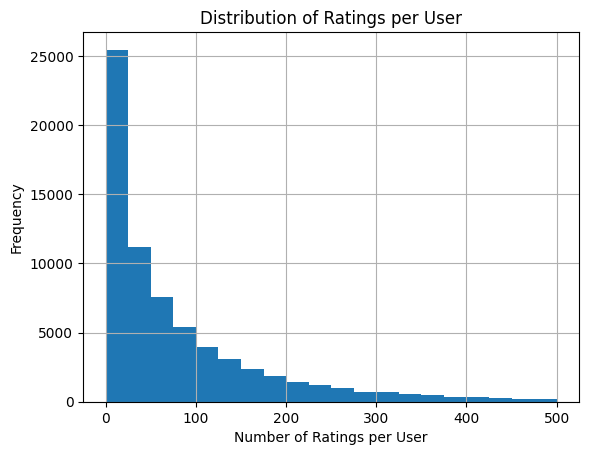

In [47]:
import matplotlib.pyplot as plt

# Plot a histogram of the number of ratings per user
ratings_per_user.hist(bins=20, range=(0,500))
plt.xlabel('Number of Ratings per User')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings per User')
plt.show()

__Observations:__
- The histogram displays a right-skewed distribution, indicating that most users have rated fewer than 100 items.
- A very small number of users have rated between 100 and 500 items, with the frequency decreasing as the number of ratings increases.
- As shown by the bars approaching zero frequency, users providing a high number of ratings are exceedingly rare.

In [48]:
# Calculate the number of ratings per anime
ratings_per_anime = ratings.groupby('anime_id')['rating'].count()

# Calculate the mean number of ratings per anime
mean_ratings_per_anime = statistics.mean(ratings_per_anime.tolist())
mean_ratings_per_anime

638.3843054296364

__Observations:__

-On average, each anime title receives approximately 638 ratings, which implies a diverse range of viewer engagement levels.

-The mean of 638 ratings per anime suggests that while some receive more attention, many others have far fewer ratings.

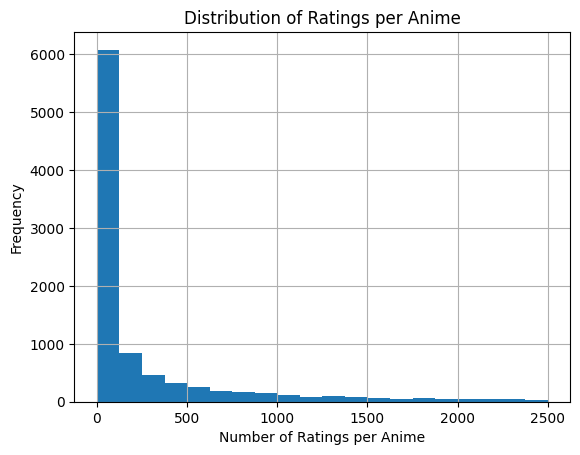

In [49]:
import matplotlib.pyplot as plt

# Plot a histogram of the number of ratings per anime
ratings_per_anime.hist(bins=20, range=(0,2500))
plt.xlabel('Number of Ratings per Anime')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings per Anime')
plt.show()

__Observations:__
- The highest frequency of anime titles has between 0 and 250 ratings, as depicted by the first bar in the histogram.
- Very few anime titles receive more than 1500 ratings, highlighting a significant drop-off in frequency as the number of ratings increases.

Create ratings per anime dataframe.
Filter ratings greater than 1000 to find a popular anime and extract the anime IDs of popular anime.

In [50]:
import pandas as pd

# Create a DataFrame from the ratings per anime data
ratings_per_anime_df = pd.DataFrame(ratings_per_anime)

# Filter the DataFrame to include only anime with 1000 or more ratings
filtered_ratings_per_anime_df = ratings_per_anime_df[ratings_per_anime_df.rating >= 1000]

# Extract the indices (anime IDs) of popular anime
popular_anime = filtered_ratings_per_anime_df.index.tolist()

In [51]:
filtered_ratings_per_anime_df

,rating
anime_id,
1,13449
5,5790
6,9385
7,2169
15,2002
...,...
32729,1802
32828,1200
32935,1038


- Create ratings per user dataframe.
- Filter ratings greater than 500 and create an index to list prolific users.

In [52]:
# Create a DataFrame from the ratings per user data
ratings_per_user_df = pd.DataFrame(ratings_per_user)

# Filter the DataFrame to include only users with 500 or more ratings
filtered_ratings_per_user_df = ratings_per_user_df[ratings_per_user_df.rating >= 500]

# Extract the indices (user IDs) of prolific users
prolific_users = filtered_ratings_per_user_df.index.tolist()

In [53]:
# Filter the ratings dataset to include only ratings for popular anime
filtered_ratings = ratings[ratings.anime_id.isin(popular_anime)]

# Further filter the ratings dataset to include only ratings from prolific users
filtered_ratings = ratings[ratings.user_id.isin(prolific_users)]

# Calculate the length of the filtered ratings dataset
len(filtered_ratings)

1005314

In [54]:
filtered_ratings

,user_id,anime_id,rating
17304,226,1,8
17305,226,6,8
17306,226,20,7
17307,226,25,6
17308,226,27,7
...,...,...,...
7812698,73502,18893,9
7812699,73502,19151,5
7812700,73502,19221,6
7812701,73502,19367,6


In [55]:
# Create a pivot table to construct the user-item rating matrix
rating_matrix = filtered_ratings.pivot_table(index='user_id', columns='anime_id', values='rating')

# Fill missing values (NaN) with 0
rating_matrix = rating_matrix.fillna(0)

# Display the first few rows of the user-item rating matrix
rating_matrix.head()

anime_id,1,5,6,7,8,15,16,17,18,19,...,34238,34239,34240,34252,34283,34324,34325,34349,34367,34475
user_id,,,,,,,,,,,,,,,,,,,,,
226,8.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
271,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
294,7.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
392,7.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
446,9.0,8.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,...,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The __user-item rating matrix__ indicates the interactions between users and items in the form of ratings. Each row represents a user, each column represents an anime title, and the values in the matrix represent the ratings given by users to the corresponding anime titles. This matrix provides a structured representation of user preferences and behaviors, serving as the foundation for collaborative filtering techniques to generate personalized recommendations.

- Define a function to find similar_users based on the cosine similarity of their rating vectors.

In [56]:
from sklearn.metrics.pairwise import cosine_similarity
import operator

def similar_users(user_id, matrix, k=3):
    # Retrieve the user's vector from the rating matrix
    user = matrix[matrix.index == user_id]

    # Exclude the user's vector from the rating matrix
    other_users = matrix[matrix.index != user_id]

    # Calculate cosine similarity between the user and other users
    similarities = cosine_similarity(user, other_users)[0].tolist()

    # Get the indices (user IDs) of other users
    indices = other_users.index.tolist()

    # Create a dictionary mapping indices to similarity scores
    index_similarity = dict(zip(indices, similarities))
   

    # Sort the dictionary by similarity scores in descending order
    index_similarity_sorted = sorted(index_similarity.items(), key=operator.itemgetter(1))
    index_similarity_sorted.reverse()
    #print(index_similarity_sorted)

    # Get the top k similar users
    top_users_similarities = index_similarity_sorted[:k]
    users = [u[0] for u in top_users_similarities]

    return users

- Test the similar_users function with a sample user ID.

In [57]:
# Define the current user's ID
current_user = 392

# Find indices of similar users to the current user
similar_user_indices = similar_users(current_user, rating_matrix)

# Print the indices of similar users
print(similar_user_indices)

[21351, 51514, 21841]


- Define a function to recommend items (animes) for a user based on the average ratings of similar users.
- Test the recommend_item function with a sample user ID and similar user indices.

In [58]:
def recommend_item(user_index, similar_user_indices, matrix, items=5):
    # Select rows corresponding to similar users
    similar_users = matrix[matrix.index.isin(similar_user_indices)]
    #print(similar_users)

    # Calculate the mean rating for each item among similar users
    similar_users = similar_users.mean(axis=0)

    # Convert the result to a DataFrame
    similar_users_df = pd.DataFrame(similar_users, columns=['mean'])
    #print(similar_users_df)

    # Select the target user's ratings
    user_df = matrix[matrix.index == user_index]
    #print(user_df)

    # Transpose the DataFrame for easier manipulation
    user_df_transposed = user_df.transpose()
    #print(user_df_transposed)

    # Rename the column for clarity
    user_df_transposed.columns = ['rating']
    #print(user_df_transposed)

    # Filter out items that the target user has not already rated
    user_df_transposed = user_df_transposed[user_df_transposed['rating']==0]
    #print(user_df_transposed)

    # Extract the indices (anime IDs) of unseen items
    animes_unseen = user_df_transposed.index.tolist()
    #print(animes_unseen)

    # Filter the DataFrame to include only ratings for unseen items
    similar_users_df_filtered = similar_users_df[similar_users_df.index.isin(animes_unseen)]
    #print(similar_users_df_filtered)

    # Sort the DataFrame by mean rating in descending order
    similar_users_df_ordered = similar_users_df.sort_values(by=['mean'], ascending=False)

    # Select the top n items with the highest mean rating
    top_n_anime = similar_users_df_ordered.head(items)
    top_n_anime_indices = top_n_anime.index.tolist()

    # Retrieve information about the recommended anime from the 'animes' dataset
    anime_information = animes[animes['anime_id'].isin(top_n_anime_indices)]

    return anime_information

recommend_item(392, similar_user_indices, rating_matrix)

,anime_id,name,genre,type,episodes,rating,members
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
13,2904,Code Geass: Hangyaku no Lelouch R2,"Action, Drama, Mecha, Military, Sci-Fi, Super ...",TV,25.0,8.98,572888
23,30276,One Punch Man,"Action, Comedy, Parody, Sci-Fi, Seinen, Super ...",TV,12.0,8.82,552458
101,18115,Magi: The Kingdom of Magic,"Action, Adventure, Fantasy, Magic, Shounen",TV,25.0,8.50,245026
178,31964,Boku no Hero Academia,"Action, Comedy, School, Shounen, Super Power",TV,13.0,8.36,282002


__Observation:__

- The function successfully generates personalized anime recommendations for a user ID 226 by averaging the ratings of similar users and suggesting titles that the target user has not yet rated.

### __Item-Based Collaborative Filtering__

Item-based collaborative filtering is a recommendation technique that suggests items to users based on the similarity between items rather than the similarity between users. It operates on the assumption that if a user has interacted positively with certain items in the past, they will likely interact positively with similar items in the future.



To measure similarity between two items \(i\) and \(j\), cosine similarity can be used:

The similarity between two items, \(i\) and \(j\), can be quantified using cosine similarity, which is particularly useful in item-based collaborative filtering. The formula for cosine similarity is as follows:

$$
\text{similarity}(i, j) = \cos(\theta) = \frac{\sum_{u \in U} r_{u,i} \cdot r_{u,j}}{\sqrt{\sum_{u \in U} r_{u,i}^2} \cdot \sqrt{\sum_{u \in U} r_{u,j}^2}}
$$

Where:

$$
\begin{align*}
&\bullet \, r_{u,i} \text{ and } r_{u,j} \text{ are ratings given by user } u \text{ to items } i \text{ and } j. \\
&\bullet \, U \text{ is the set of users who have rated both items.} \\
&\bullet \, \theta \text{ is the angle between the rating vectors of items } i \text{ and } j, \text{ where a smaller angle indicates a higher similarity.}
\end{align*}
$$

This approach calculates the cosine of the angle between the two items' rating vectors, effectively measuring their similarity based on the ratings they have received from users.

### Predicting User Ratings for Item-Based Collaborative Filtering




To predict the rating that a user \(u\) would give to an item \(i\) using item-based collaborative filtering, we use the weighted sum of the user's ratings for similar items:

$$
\hat{r}_{u,i} = \frac{\sum_{j \in S} \text{sim}(i, j) \cdot r_{u,j}}{\sum_{j \in S} |\text{sim}(i, j)|}
$$

Where:

$$
\begin{align*}
&\bullet \, \hat{r}_{u,i} \text{ is the predicted rating for user } u \text{ on item } i. \\
&\bullet \, S \text{ is the set of items rated by user } u \text{ that are similar to item } i. \\
&\bullet \, \text{sim}(i, j) \text{ is the similarity between item } i \text{ and item } j. \\
&\bullet \, r_{u,j} \text{ is the rating of user } u \text{ for item } j.
\end{align*}
$$

__Example:__

In [59]:
# Import the pandas library for data manipulation
import pandas as pd

# Import the cosine_similarity function from the sklearn.metrics.pairwise module
from sklearn.metrics.pairwise import cosine_similarity

- Create a dictionary with users and their ratings for different web series.

In [60]:
# Define the dataset representing ratings given by users to various TV shows
dataset = {
    'user1': {'Mindhunter': 5, 'You': 3, 'Dexter': 3, 'Mr. Robot': 3, 'True Detective': 2, 'Twin Peaks': 3},
    'user2': {'Mindhunter': 5, 'You': 3, 'Mr. Robot': 5, 'Dexter': 5, 'Twin Peaks': 3, 'True Detective': 3},
    'user3': {'Mindhunter': 2, 'Dexter': 5, 'Mr. Robot': 3},
    'user4': {'Dexter': 5, 'Twin Peaks': 4, 'Mr. Robot': 4},
    'user5': { 'You': 4, 'Dexter': 4, 'Twin Peaks': 3},
    'user6': {'Mindhunter': 3,  'Twin Peaks': 3,  'True Detective': 3},
    'user7': {'Dexter': 4, 'True Detective': 1, 'Mr. Robot': 4}
}

__Observation:__
- The dataset is based on the number of users, the web series they watched, and the rating given by them.

In [61]:
# Convert the dataset dictionary to a DataFrame
dataset_df = pd.DataFrame(dataset)

# Fill missing values (NaN) with "Not Seen Yet"
dataset_df.fillna("Not Seen Yet", inplace=True)

# Display the DataFrame
dataset_df

C:\Users\Deepak Pandey\AppData\Local\Temp\ipykernel_24520\635979391.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not Seen Yet' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dataset_df.fillna("Not Seen Yet", inplace=True)


,user1,user2,user3,user4,user5,user6,user7
Mindhunter,5,5,2.0,Not Seen Yet,Not Seen Yet,3.0,Not Seen Yet
You,3,3,Not Seen Yet,Not Seen Yet,4.0,Not Seen Yet,Not Seen Yet
Dexter,3,5,5.0,5.0,4.0,Not Seen Yet,4.0
Mr. Robot,3,5,3.0,4.0,Not Seen Yet,Not Seen Yet,4.0
True Detective,2,3,Not Seen Yet,Not Seen Yet,Not Seen Yet,3.0,1.0
Twin Peaks,3,3,Not Seen Yet,4.0,3.0,3.0,Not Seen Yet


- Create a custom function to get the unique web series in the dataset.

In [62]:
def unique_items():
    # Initialize an empty list to store unique items
    unique_items_list = []

    # Iterate through each person in the dataset
    for person in dataset.keys():
        # Iterate through the items rated by each person
        for items in dataset[person]:
            # Append each item to the unique_items_list
            unique_items_list.append(items)

    # Convert the list to a set to remove duplicates
    s = set(unique_items_list)

    # Convert the set back to a list to maintain the order of items
    unique_items_list = list(s)

    # Return the list of unique items
    return unique_items_list

In [63]:
# Call the unique_items() function to obtain a list of unique items present in the dataset
unique_items()

['You', 'Mr. Robot', 'Dexter', 'Twin Peaks', 'True Detective', 'Mindhunter']

- Define a function that determines the similarity between two items based on their ratings. This function iterates through the dataset to identify individuals' common ratings for both items. It then calculates the cosine similarity between the ratings of item 1 and item 2.

In [64]:
def item_similarity(item1, item2):
    # Initialize a dictionary to store ratings of both items by common users
    both_rated = {}

    # Iterate through each person in the dataset
    for person in dataset.keys():
        # Check if both items are rated by the current person
        if item1 in dataset[person] and item2 in dataset[person]:
            # Store the ratings of both items by the current person
            both_rated[person] = [dataset[person][item1], dataset[person][item2]]

    # Calculate the number of ratings both items share
    number_of_ratings = len(both_rated)

    # If there are no common ratings, return 0 (indicating no similarity)
    if number_of_ratings == 0:
        return 0

    # Extract ratings of item1 and item2 by common users
    item1_ratings = [[dataset[k][item1] for k, v in both_rated.items() if item1 in dataset[k] and item2 in dataset[k]]]
    item2_ratings = [[dataset[k][item2] for k, v in both_rated.items() if item1 in dataset[k] and item2 in dataset[k]]]

    # Calculate cosine similarity between item1 and item2 ratings
    cs = cosine_similarity(item1_ratings, item2_ratings)

    # Return the cosine similarity score
    return cs[0][0]

In [65]:
# Print the cosine similarity between 'Dexter' and 'Mr. Robot' based on their ratings
print("Cosine Similarity:", item_similarity('Dexter', 'Mr. Robot'))

Cosine Similarity: 0.9814954576223638


- Define a function to determine similar items to a specified target item. This function calculates the similarity scores between the target item and all other items in the dataset. Then, it sorts these similarity scores in descending order and returns the sorted list.

In [66]:
def most_similar_items(target_item):
    # Obtain a list of all unique items
    un_lst = unique_items()

    # Calculate similarity scores between the target item and all other items
    scores = [(item_similarity(target_item, other_item), target_item + " --> " + other_item) for other_item in un_lst if other_item != target_item]

    # Sort the similarity scores in descending order
    scores.sort(reverse=True)

    # Return the sorted similarity scores
    return scores

In [67]:
# Print the most similar items to 'Dexter' based on their similarity scores
print(most_similar_items('Dexter'))

[(np.float64(0.9861050150846985), 'Dexter --> Twin Peaks'), (np.float64(0.9814954576223638), 'Dexter --> Mr. Robot'), (np.float64(0.9701425001453318), 'Dexter --> You'), (np.float64(0.944911182523068), 'Dexter --> True Detective'), (np.float64(0.8858233390878899), 'Dexter --> Mindhunter')]


- Define a function to recommend movies to a target user by identifying the movies they have not rated. The function collects the movies rated by the target user and calculates the set difference between all movies and the ones rated by the target user. It returns the list of recommended movies along with the list of movies rated by the target user.

### __Cold start problem__



The cold start problem refers to a challenge encountered by recommender systems when they are unable to effectively make recommendations for new users or items with limited or no historical data. In other words, when there isn't enough information about a user's preferences or about newly added items, it becomes difficult for the recommender system to accurately predict what the user might like. This can result in less personalized or inaccurate recommendations until sufficient data is collected to better understand the user or item.


#### Types of Cold Start Problems

- **User Cold Start Problem**: This arises when there is almost no information available about the user, making it difficult to generate personalized recommendations.
- **Item Cold Start Problem**: This occurs when there is almost no information available about a product, making it difficult to recommend it to users effectively.


#### Reasons for Cold Start Problems

- **Systematic Bootstrapping**: Starting the system with limited data makes it difficult to give accurate recommendations to new users or items.
- **Low Interaction**: Minimal user engagement results in sparse data, making it difficult for the recommender system to understand preferences.
- **New User**: Lack of historical data for new users hampers personalized recommendations until enough interaction data is collected.


#### Mitigation Techniques

Mitigation techniques refer to employing strategies to tackle challenges or lessen the effects of issues encountered within a system or process with the goal of improving performance or effectiveness. The following are the primary techniques employed for mitigation:

- **Representative Approach**: Using samples or subsets of data that accurately reflect the characteristics of a larger dataset ensures reliable analysis and decision-making.
- **Feature Mapping**: Transforming input variables into a different representation improves the performance or interpretability of machine learning models.
- **Hybrid Approach**: Combining various methods or models aims to achieve superior performance or address diverse requirements effectively.


### __Implicit and Explicit Feedback__

In recommendation systems, implicit and explicit feedback are two types of signals used to understand user preferences.


- **Explicit Feedback**: This refers to direct and clear indications of user preferences provided explicitly by the user. For example, ratings, reviews, likes, or dislikes expressed by users explicitly convey their opinions or preferences for certain items.
- **Implicit Feedback**: This type of feedback is inferred from user behavior or interactions with the system without any explicit input from the user. It includes actions such as clicks, purchases, browsing history, time spent on items, or mouse movements. Implicit feedback relies on interpreting user actions to understand their preferences and interests.
